# Lecture 15: Support Vector Machines

**F&W ECOL 458 — Environmental Data Science**

Reference: [scikit-learn SVM documentation](https://scikit-learn.org/stable/modules/svm.html)

---

### Learning objectives

By the end of this lecture you should be able to:

1. Explain what a hyperplane, margin, and support vector are and how they relate to classification.
2. Describe why the kernel trick is needed and what an RBF kernel does.
3. Interpret the regularization parameter $C$ and its effect on the decision boundary.
4. Construct and interpret an ROC curve and compute AUC.
5. Train an SVM classifier in `scikit-learn` and evaluate its performance.


## 1. Finding the Best Decision Boundary

Let's start with a simple two-class dataset and ask: *how should we draw the line that separates the classes?*


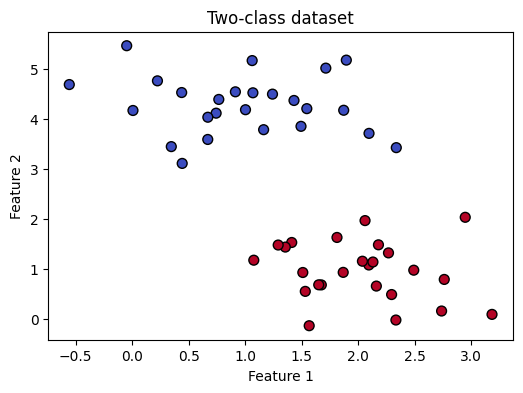

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Two well-separated clusters
X, y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.6)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two-class dataset")
plt.show()


Imagine you are mapping two habitat types — say, **wetland** vs. **upland** — based on two spectral indices. Every pixel is a point in this 2-D feature space, and you want a line that separates them.

Many lines could work. But which is best?


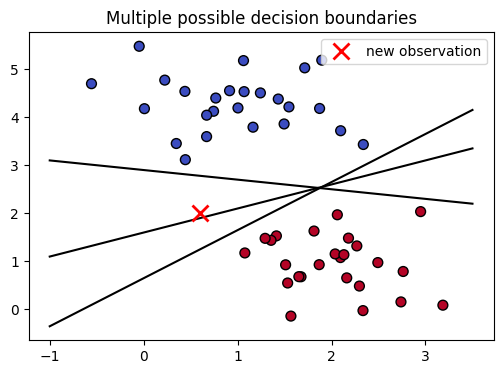

In [ ]:
import numpy as np

xfit = np.linspace(-1, 3.5)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=50)

# Three candidate decision boundaries
for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, "k-")

# A new, ambiguous point
plt.plot(0.6, 2, "rx", markersize=12, markeredgewidth=2, label="new observation")
plt.legend()
plt.title("Multiple possible decision boundaries")
plt.show()


Each of those three lines correctly separates the training data. But the red x would be classified differently depending on which line we choose — so the choice matters.

**Key insight:** we should prefer the line that leaves the *widest gap* (called the **margin**) between the classes. A wider margin makes the classifier more robust to new data and less likely to overfit.


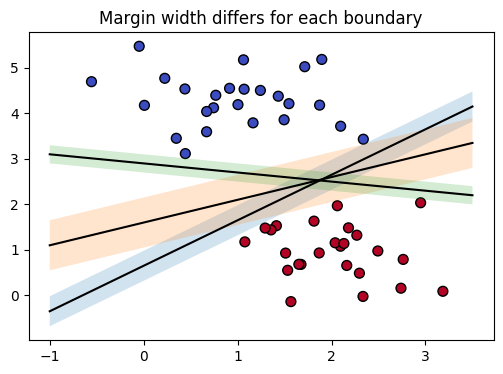

In [ ]:
import numpy as np

xfit = np.linspace(-1, 3.5)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=50)

# Show the margin band for each candidate line
for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, "k-")
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor="none", alpha=0.2)

plt.title("Margin width differs for each boundary")
plt.show()


The middle line has the **widest margin**. The algorithm that finds this maximum-margin boundary is the **Support Vector Machine (SVM)**.


## 2. Fitting an SVM

Let's use `scikit-learn` to find the optimal boundary and visualize the margin and support vectors.


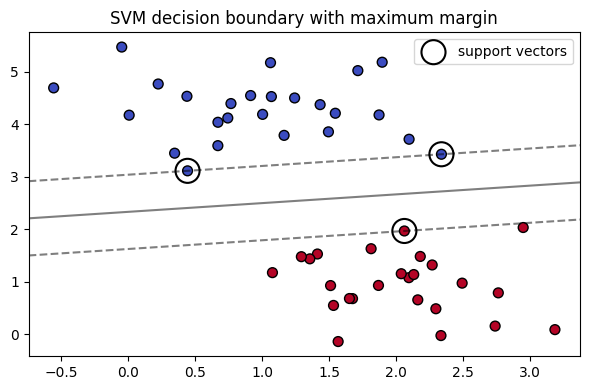

Number of support vectors: 3
Support vector coordinates:
[[0.44359863 3.11530945]
 [2.33812285 3.43116792]
 [2.06156753 1.96918596]]


In [ ]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# Fit a linear SVM with very large C (hard margin)
model = SVC(kernel="linear", C=1e10)
model.fit(X, y)

# ── Helper function: plot decision boundary + margins ──
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision boundary, margins, and support vectors for a 2-D SVC."""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Evaluate decision function on a grid
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)

    # Decision boundary (solid) and margins (dashed)
    ax.contour(XX, YY, Z, colors="k",
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=["--", "-", "--"])

    # Highlight support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, edgecolors="k", facecolors="none",
                   linewidths=1.5, label="support vectors")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

# ── Plot ──
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=50)
plot_svc_decision_function(model, ax)
ax.set_title("SVM decision boundary with maximum margin")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Number of support vectors: {len(model.support_vectors_)}")
print(f"Support vector coordinates:\n{model.support_vectors_}")


### Key terminology

- **Hyperplane:** the decision boundary. In 2-D it is a line; in 3-D a plane; in higher dimensions a *hyperplane*.
- **Margin:** the distance between the hyperplane and the nearest data points from either class. SVM maximizes this margin.
- **Support vectors:** the training points that lie exactly on the margin boundaries. They alone determine the position and orientation of the hyperplane — all other points could be removed without changing the result.

### How SVM works (conceptual steps)

1. **Represent the data** in an $M$-dimensional feature space (one axis per feature).
2. **Search for the hyperplane** that separates the two classes with the **largest margin**.
3. **Identify the support vectors** — the points closest to the hyperplane that define the margin.
4. **Solve the optimization problem** — mathematically, SVM maximizes the margin subject to the constraint that all training points are on the correct side (or within a tolerance controlled by the parameter $C$).


## 3. What if the Data Are Not Linearly Separable?

Many real-world datasets cannot be separated by a straight line. Consider this circular arrangement:


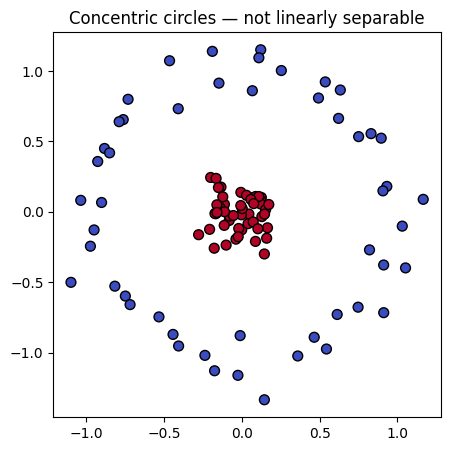

In [ ]:
from sklearn.datasets import make_circles

X_circ, y_circ = make_circles(100, factor=0.1, noise=0.1, random_state=0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap="coolwarm",
           edgecolors="k", s=50)
ax.set_title("Concentric circles — not linearly separable")
plt.show()


A linear SVM will fail here:


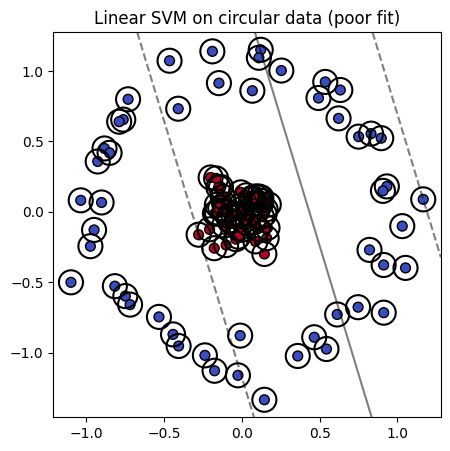

In [ ]:
clf_lin = SVC(kernel="linear").fit(X_circ, y_circ)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap="coolwarm",
           edgecolors="k", s=50)
plot_svc_decision_function(clf_lin, ax, plot_support=True)
ax.set_title("Linear SVM on circular data (poor fit)")
plt.show()


### Projecting into a higher dimension

The trick is to **add a new feature** that makes the classes linearly separable in a higher-dimensional space. For example, we can compute a radial basis function (distance from the origin):

$$
r_i = \exp\!\Bigl(-\sum_j x_{ij}^2\Bigr)
$$

Points near the center get a high $r$ value; points far from the center get a low $r$ value. In this new 3-D space ($x_1, x_2, r$) the two rings separate vertically — and a flat plane can cut between them.


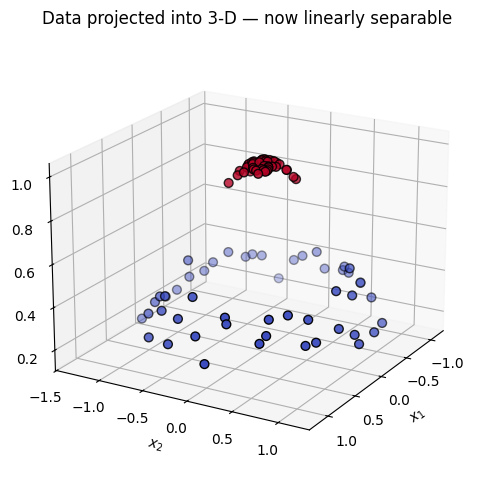

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Compute the radial basis feature
r = np.exp(-(X_circ ** 2).sum(axis=1))

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_circ[:, 0], X_circ[:, 1], r, c=y_circ, cmap="coolwarm",
           edgecolors="k", s=40)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$r$")
ax.set_title("Data projected into 3-D — now linearly separable")
ax.view_init(elev=20, azim=30)
plt.tight_layout()
plt.show()


### The Kernel Trick

Computing new features explicitly for every pair of points can be expensive (imagine thousands of features). The **kernel trick** avoids this by computing dot products in the high-dimensional space *without ever constructing that space explicitly*. The SVM algorithm only needs these dot products (called **kernel values**) to find the optimal hyperplane.

Common kernel functions:

| Kernel | `sklearn` name | When to try it |
|---|---|---|
| Linear | `"linear"` | Data are (approximately) linearly separable |
| Polynomial | `"poly"` | Moderate nonlinearity |
| Radial Basis Function (RBF) | `"rbf"` | General-purpose; most commonly used default |
| Sigmoid | `"sigmoid"` | Occasionally used; similar to a neural-network activation |

Let's re-fit the circular data using an RBF kernel:


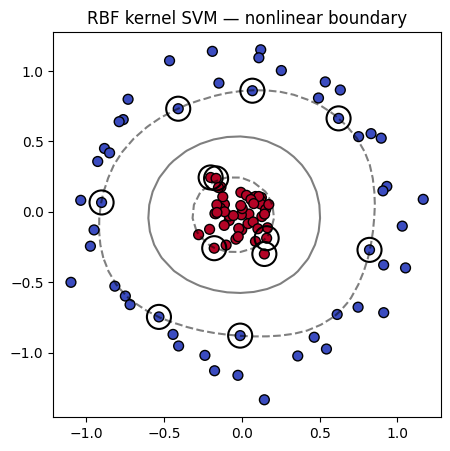

In [ ]:
clf_rbf = SVC(kernel="rbf").fit(X_circ, y_circ)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap="coolwarm",
           edgecolors="k", s=50)
plot_svc_decision_function(clf_rbf, ax, plot_support=True)
ax.set_title("RBF kernel SVM — nonlinear boundary")
plt.show()


## 4. Soft Margins and the Regularization Parameter $C$

Real-world data almost always have some overlap between classes. A **hard margin** SVM (very large $C$) demands perfect separation and can overfit noisy data. A **soft margin** SVM (smaller $C$) tolerates some misclassifications in exchange for a wider, more generalizable margin.

- **Large $C$** → narrow margin, fewer misclassifications on training data, risk of overfitting.
- **Small $C$** → wide margin, more tolerant of misclassifications, better generalization.

Think of $C$ as a dial between *"get every training point right"* and *"keep the margin wide."*


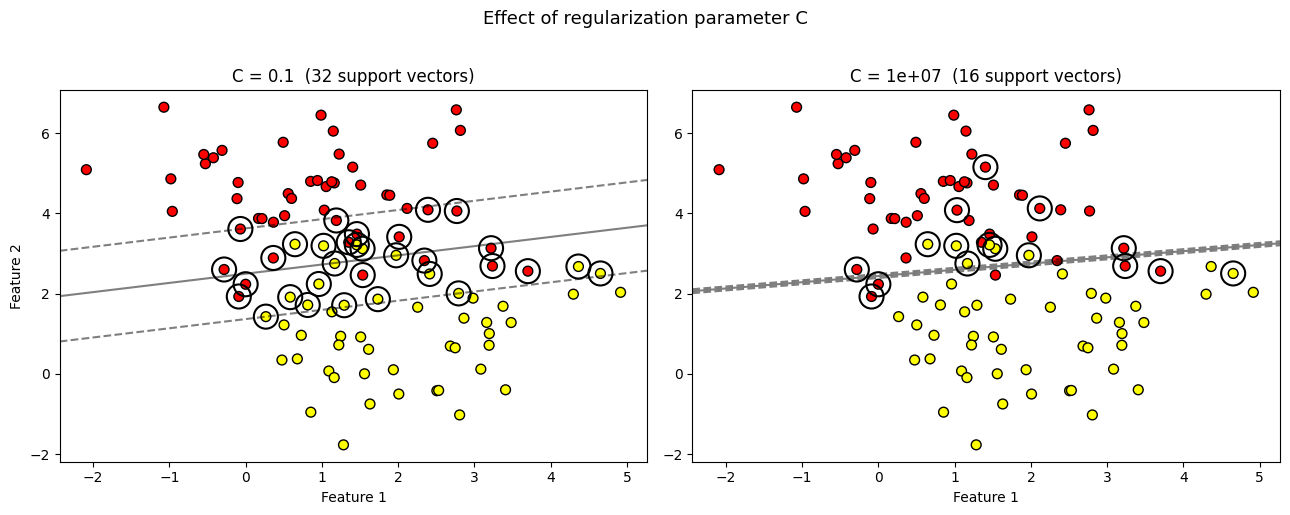

In [ ]:
X_overlap, y_overlap = make_blobs(n_samples=100, centers=2,
                                  random_state=0, cluster_std=1.2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, C_val in zip(axes, [0.1, 1e7]):
    model_c = SVC(kernel="linear", C=C_val).fit(X_overlap, y_overlap)
    ax.scatter(X_overlap[:, 0], X_overlap[:, 1], c=y_overlap,
               cmap="autumn", edgecolors="k", s=50)
    plot_svc_decision_function(model_c, ax)
    ax.set_title(f"C = {C_val:g}  ({len(model_c.support_vectors_)} support vectors)")

axes[0].set_ylabel("Feature 2")
for ax in axes:
    ax.set_xlabel("Feature 1")
plt.suptitle("Effect of regularization parameter C", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


> **Discussion prompt:** In a land-cover classification task where your training labels come from visual photo-interpretation (and therefore contain some labeling errors), would you choose a large or small $C$? Why?


## 5. Evaluating Binary Classifiers: ROC Curves and AUC

In Lecture 14 we introduced the confusion matrix, precision, recall, and F1. Here we add two more evaluation tools that are especially useful when you want to understand classifier performance **across all possible decision thresholds**.

### True Positive Rate and False Positive Rate

Recall (also called the **True Positive Rate**, TPR):

$$
\text{TPR} = \frac{TP}{TP + FN}
$$

The **False Positive Rate** (FPR):

$$
\text{FPR} = \frac{FP}{FP + TN}
$$

### The ROC curve

An **ROC (Receiver Operating Characteristic) curve** plots TPR vs. FPR as we sweep the classification threshold from 0 to 1. Each threshold yields a different (FPR, TPR) pair — tracing out a curve.

- A **perfect classifier** hugs the top-left corner (TPR = 1, FPR = 0).
- A **random classifier** follows the diagonal (TPR = FPR).

### AUC (Area Under the ROC Curve)

The AUC summarizes the ROC curve as a single number:

| AUC | Interpretation |
|---|---|
| 1.0 | Perfect separation |
| 0.7 – 0.9 | Good to excellent discrimination |
| 0.5 | No better than random guessing |
| < 0.5 | Worse than random (predictions are inverted) |

AUC is particularly useful when classes are imbalanced — a situation common in environmental science (e.g., rare species detection, wildfire occurrence).


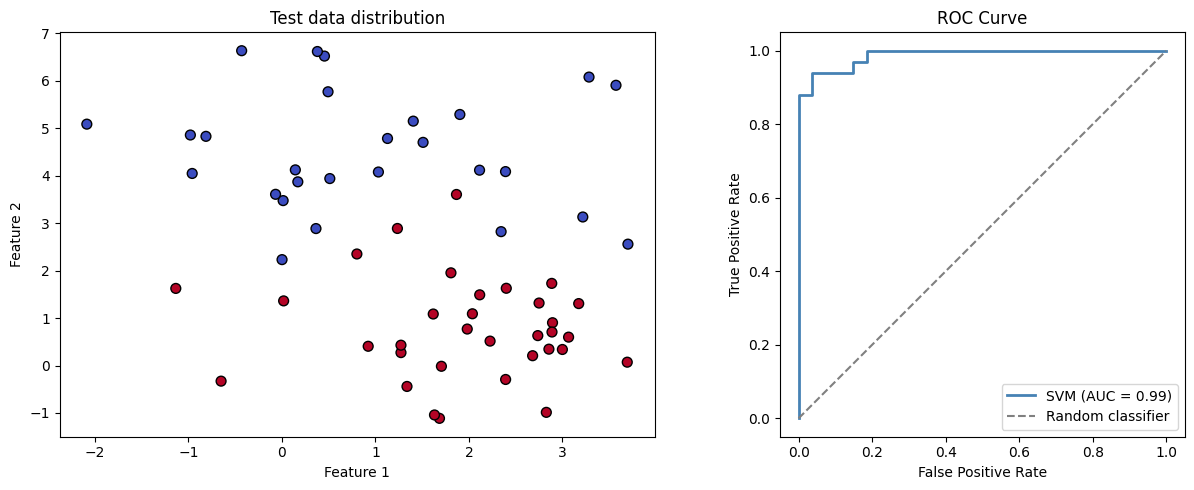

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score

# Generate overlapping two-class data
X_roc, y_roc = make_blobs(n_samples=200, centers=2,
                           random_state=0, cluster_std=1.2)

X_train, X_test, y_train, y_test = train_test_split(
    X_roc, y_roc, test_size=0.3, random_state=42
)

# Train SVM with probability estimates enabled
model_roc = SVC(kernel="linear", C=10, probability=True)
model_roc.fit(X_train, y_train)

# Predicted probabilities for the positive class
y_proba = model_roc.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: test data
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test,
                cmap="coolwarm", edgecolors="k", s=50)
axes[0].set_title("Test data distribution")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# Right: ROC curve
axes[1].plot(fpr, tpr, color="steelblue", linewidth=2,
             label=f"SVM (AUC = {auc_score:.2f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()


### Ecological context

ROC curves are widely used in species-distribution modeling (SDMs) to evaluate how well a model discriminates between sites where a species is present vs. absent. An AUC of 0.5 means the model is no better than flipping a coin; values above 0.8 are generally considered useful for management decisions.

> **Caveat:** AUC can be misleading when the study area is very large relative to the species' range, because many "easy" absences inflate performance. Always pair AUC with ecologically informed evaluation (e.g., partial AUC focusing on low FPR).


## 6. Summary

| Concept | Key takeaway |
|---|---|
| SVM goal | Find the maximum-margin hyperplane separating two classes |
| Support vectors | The training points on the margin boundary; they alone define the hyperplane |
| Kernel trick | Maps data to higher dimensions implicitly, enabling nonlinear decision boundaries |
| RBF kernel | General-purpose kernel; usually a good first choice |
| Parameter $C$ | Controls the bias-variance tradeoff: small $C$ → wide margin (may underfit); large $C$ → narrow margin (may overfit) |
| ROC curve | Plots TPR vs. FPR across all thresholds; a perfect classifier hugs the top-left corner |
| AUC | Single-number summary of the ROC curve; 1.0 = perfect, 0.5 = random |

### When to use SVM

SVMs work well when the number of features is large relative to the number of samples (common in remote-sensing applications), and when you want a robust classifier with solid theoretical foundations. They are less convenient for very large datasets (training scales roughly as $O(N^2)$-$O(N^3)$) and do not produce probability estimates by default (though `scikit-learn` can estimate them with Platt scaling via `probability=True`).
